In [664]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

In [665]:
ev_data = pd.read_csv("../data/heavy_user.csv")
ev_data

,Unnamed: 0,SOC,SOH,Charging_Cycles,Battery_Temp,Motor_RPM,Motor_Torque,Motor_Temp,Brake_Pad_Wear,Charging_Voltage,Tire_Pressure,DTC
0,2020-01-01 00:00:00,20.000000,99.999757,0,31.822998,0.0,0.0,64.937230,100.000000,400,34.987175,0
1,2020-01-01 01:00:00,20.000000,99.999495,0,31.596741,0.0,0.0,71.637683,100.000000,400,34.976006,0
2,2020-01-01 02:00:00,20.000000,99.999244,0,31.694791,0.0,0.0,76.626964,100.000000,400,34.961510,0
3,2020-01-01 03:00:00,20.000000,99.998996,0,29.370583,0.0,0.0,73.446945,100.000000,400,34.949125,0
4,2020-01-01 04:00:00,20.000000,99.998749,0,30.808790,0.0,0.0,70.240659,100.000000,400,34.935932,0
...,...,...,...,...,...,...,...,...,...,...,...,...
43795,2024-12-29 19:00:00,41.896804,90.120302,29,30.644411,0.0,0.0,73.274256,57.599885,400,29.247296,0
43796,2024-12-29 20:00:00,41.896804,90.120050,29,31.478640,0.0,0.0,71.116980,57.599885,400,29.235478,0
43797,2024-12-29 21:00:00,41.896804,90.119788,29,28.318739,0.0,0.0,71.968694,57.599885,400,29.220806,0
43798,2024-12-29 22:00:00,41.896804,90.119528,29,30.484194,0.0,0.0,70.822133,57.599885,400,29.209373,0


In [666]:
# give the timestamp column a name
ev_data.rename(columns={"Unnamed: 0": "TimeStamp"}, inplace=True)

In [667]:
# convert the timestamps to datetime objects such that we can make comparisons
ev_data["TimeStamp"] = pd.to_datetime(ev_data["TimeStamp"])

In [668]:
# the charging voltage is a constant so not informative for the AI models (this step should be part of the pipeline)
ev_data.drop("Charging_Voltage", axis=1, inplace=True)
ev_data

,TimeStamp,SOC,SOH,Charging_Cycles,Battery_Temp,Motor_RPM,Motor_Torque,Motor_Temp,Brake_Pad_Wear,Tire_Pressure,DTC
0,2020-01-01 00:00:00,20.000000,99.999757,0,31.822998,0.0,0.0,64.937230,100.000000,34.987175,0
1,2020-01-01 01:00:00,20.000000,99.999495,0,31.596741,0.0,0.0,71.637683,100.000000,34.976006,0
2,2020-01-01 02:00:00,20.000000,99.999244,0,31.694791,0.0,0.0,76.626964,100.000000,34.961510,0
3,2020-01-01 03:00:00,20.000000,99.998996,0,29.370583,0.0,0.0,73.446945,100.000000,34.949125,0
4,2020-01-01 04:00:00,20.000000,99.998749,0,30.808790,0.0,0.0,70.240659,100.000000,34.935932,0
...,...,...,...,...,...,...,...,...,...,...,...
43795,2024-12-29 19:00:00,41.896804,90.120302,29,30.644411,0.0,0.0,73.274256,57.599885,29.247296,0
43796,2024-12-29 20:00:00,41.896804,90.120050,29,31.478640,0.0,0.0,71.116980,57.599885,29.235478,0
43797,2024-12-29 21:00:00,41.896804,90.119788,29,28.318739,0.0,0.0,71.968694,57.599885,29.220806,0
43798,2024-12-29 22:00:00,41.896804,90.119528,29,30.484194,0.0,0.0,70.822133,57.599885,29.209373,0


In [669]:
# here we can see that it is likely that the battery has been replaced multiple times as Charging_Cycles is set to 0 on multiple occassions
fig = px.line(ev_data, x="TimeStamp", y="Charging_Cycles", title="Number of charging cycles of the EV")
fig.show()

In [670]:
# here we can see that one specific dtc(P0B) is connected to the battery as when battery cycles is reset to 0, there was a DTC during that time except for one case  
fig = px.line(ev_data, x="TimeStamp", y="DTC", title="Diagnostic Trouble Code")
fig.show()

In [671]:
# one case where the health of the battery 
fig = px.line(ev_data, x="TimeStamp", y="SOH", title="State of Health (Battery)")
fig.show()

In [672]:
ev_data_2021_oct = ev_data[(ev_data["TimeStamp"].dt.year == 2021) & (ev_data["TimeStamp"].dt.month == 10)]
fig = px.line(ev_data_2021_oct, x="TimeStamp", y="SOC", title="State of Charge (Battery)")
fig.show()

In [673]:
# daily pattern is visible
fig = px.line(ev_data_2021_oct, x="TimeStamp", y="Motor_Torque", title="The Torque of the Motor")
fig.show()

In [674]:
# pattern seems to repeats around 23-24 days, 4 dec 2021 we see a sudden drop in pressure which coincides with a DTC
ev_data_2021 = ev_data[ev_data["TimeStamp"].dt.year == 2021]
fig = px.line(ev_data_2021, x="TimeStamp", y="Tire_Pressure", title="The Tire Pressure")
fig.show()

In [675]:
# TODO: add a feature representing the month/season based on the timestamp

In [676]:
# what we might be able to do is create individual models for some features that have clear periodical behaviour, we can see for example a clear pattern in state of charge,
# etc but for some the sampling frequency of an hour is not high enough as this should be at least 2 times the highest frequency of the signal according to the "Nyquist-Shannon sampling theorem"
# e.g., the motor torque has a daily pattern i.e. nonzero torque during day and zero torque during night. However, other patterns during driving are probably not captured by the
# hourly sampling rate. If i want to have some univariate models to obtain anomaly info only on a specific feature: https://blog.jetbrains.com/pycharm/2025/01/anomaly-detection-in-time-series/
# one of the advantages of the ML approaches such as isolation forrest and multivariate autoencoders is that you can also see anomalies caused by the combination of multiple 
# features

In [679]:
#check the data where there is a DTC
ev_data[ev_data["DTC"] != "0"]

,TimeStamp,SOC,SOH,Charging_Cycles,Battery_Temp,Motor_RPM,Motor_Torque,Motor_Temp,Brake_Pad_Wear,Tire_Pressure,DTC
64,2020-01-03 16:00:00,100.000000,99.972906,2,29.634989,1395.020488,279.004098,69.994426,99.517249,34.195862,P0MR
133,2020-01-06 13:00:00,54.408731,99.950915,2,28.602932,1340.043911,268.008782,69.906038,99.255273,33.341432,P0MR
153,2020-01-07 09:00:00,35.514163,99.943888,2,32.547141,1325.271854,265.054371,68.554872,99.146239,33.101870,P0MR
202,2020-01-09 10:00:00,56.786750,99.924500,3,32.336645,1388.915325,277.783065,73.582733,98.803817,32.508910,P0MR
226,2020-01-10 10:00:00,28.344328,99.915479,3,30.550705,1293.170534,258.634107,66.106977,98.641303,32.213739,P0MR
...,...,...,...,...,...,...,...,...,...,...,...
43662,2024-12-24 06:00:00,97.845707,90.168801,28,36.269131,1399.620407,279.924081,70.508301,58.375664,30.887573,P0MR
43670,2024-12-24 14:00:00,78.927723,90.164746,28,31.639869,1333.152236,266.630447,71.446839,58.267073,30.790935,P0MR
43692,2024-12-25 12:00:00,54.775454,90.156814,28,36.543151,1352.380854,270.476171,65.474802,58.131868,30.517928,P0MR
43740,2024-12-27 12:00:00,77.541319,90.137773,29,36.062278,4604.708704,920.941741,105.380612,57.801716,29.933706,P0MT


In [680]:
# obtain list with features that need rolling window and lag features
features_excluded = ["DTC", "TimeStamp"]
ev_reduced_cols = [col for col in ev_data.columns if col not in features_excluded]
ev_reduced_cols

['SOC',
 'SOH',
 'Charging_Cycles',
 'Battery_Temp',
 'Motor_RPM',
 'Motor_Torque',
 'Motor_Temp',
 'Brake_Pad_Wear',
 'Tire_Pressure']

In [ ]:
#this is only for the training and testing of the model for runtime predictions we need to obtain the lag features via the historical states in the digital twin
# here we can just shift the columns because we already have the full dataset.

#TODO: morgen even overleggen of we dit erin houden of niet

# set the size for the lag and window features
window_lag_size = 100

#
for col in ev_reduced_cols:
     
     # add the rolling features
     ev_data[f"{col}_rolling-{window_lag_size}_mean"] = ev_data[col].rolling(window=window_lag_size, min_periods=window_lag_size).std()
     ev_data[f"{col}_rolling-{window_lag_size}_mean"] = ev_data[col].rolling(window=window_lag_size, min_periods=window_lag_size).mean()
     
     # add the lag features
     for i in range(1, window_lag_size + 1):
        ev_data[f"{col}_lag-{i}"] = ev_data[col].shift(i)


# this drops the first window_lag_size rows/hours of data because the lag features have missing values because there is not enough historical data available yet
ev_data.dropna(inplace=True)

ev_data




C:\Users\jaspe\AppData\Local\Temp\ipykernel_32784\1423296983.py:18: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\jaspe\AppData\Local\Temp\ipykernel_32784\1423296983.py:18: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\jaspe\AppData\Local\Temp\ipykernel_32784\1423296983.py:18: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragment

,TimeStamp,SOC,SOH,Charging_Cycles,Battery_Temp,Motor_RPM,Motor_Torque,Motor_Temp,Brake_Pad_Wear,Tire_Pressure,...,Tire_Pressure_lag-3,Tire_Pressure_lag-4,Tire_Pressure_lag-5,Tire_Pressure_lag-6,Tire_Pressure_lag-7,Tire_Pressure_lag-8,Tire_Pressure_lag-9,Tire_Pressure_lag-10,Tire_Pressure_lag-11,Tire_Pressure_lag-12
12,2020-01-01 12:00:00,85.539082,99.993980,1,32.278729,3058.701791,611.740358,89.695196,99.904608,34.836012,...,34.872329,34.887148,34.901871,34.913757,34.924030,34.935932,34.949125,34.961510,34.976006,34.987175
13,2020-01-01 13:00:00,83.309686,99.993498,1,30.951538,2871.761063,574.352213,84.381788,99.891428,34.825971,...,34.860275,34.872329,34.887148,34.901871,34.913757,34.924030,34.935932,34.949125,34.961510,34.976006
14,2020-01-01 14:00:00,81.035525,99.993007,1,29.263469,3030.970626,606.194125,86.291695,99.877240,34.815221,...,34.846403,34.860275,34.872329,34.887148,34.901871,34.913757,34.924030,34.935932,34.949125,34.961510
15,2020-01-01 15:00:00,78.553041,99.992490,1,31.060231,1559.297546,311.859509,69.314571,99.863611,34.802323,...,34.836012,34.846403,34.860275,34.872329,34.887148,34.901871,34.913757,34.924030,34.935932,34.949125
16,2020-01-01 16:00:00,76.257874,99.991999,1,33.145971,1568.863931,313.772786,69.134167,99.851134,34.791877,...,34.825971,34.836012,34.846403,34.860275,34.872329,34.887148,34.901871,34.913757,34.924030,34.935932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43795,2024-12-29 19:00:00,41.896804,90.120302,29,30.644411,0.000000,0.000000,73.274256,57.599885,29.247296,...,29.282763,29.295354,29.307543,29.319531,29.333112,29.344833,29.355790,29.366791,29.379067,29.389141
43796,2024-12-29 20:00:00,41.896804,90.120050,29,31.478640,0.000000,0.000000,71.116980,57.599885,29.235478,...,29.271511,29.282763,29.295354,29.307543,29.319531,29.333112,29.344833,29.355790,29.366791,29.379067
43797,2024-12-29 21:00:00,41.896804,90.119788,29,28.318739,0.000000,0.000000,71.968694,57.599885,29.220806,...,29.257843,29.271511,29.282763,29.295354,29.307543,29.319531,29.333112,29.344833,29.355790,29.366791
43798,2024-12-29 22:00:00,41.896804,90.119528,29,30.484194,0.000000,0.000000,70.822133,57.599885,29.209373,...,29.247296,29.257843,29.271511,29.282763,29.295354,29.307543,29.319531,29.333112,29.344833,29.355790


In [682]:
n_months = 12
n_days = 7
n_hours = 24

# extract series containing temporal info, i.e. month day of the week, and the hour
months = ev_data["TimeStamp"].dt.month
days = ev_data["TimeStamp"].dt.dayofweek
hours = ev_data["TimeStamp"].dt.hour

# To maintain some temporal information we do cyclic encoding on the month day and hour extracted from the timestamp. This is cleaner and represents the cyclic pattern better.
# Both the sine and cosine necessary to maintain the full info 
ev_data["Cosine_Month"] = np.cos((2 * np.pi / n_months) * months)
ev_data["Sine_Month"] = np.sin((2 * np.pi / n_months) * months)

ev_data["Cosine_Day"] = np.cos((2 * np.pi / n_days) * days)
ev_data["Sine_Day"] = np.sin((2 * np.pi / n_days) * days)

ev_data["Cosine_Hour"] = np.cos((2 * np.pi / n_hours) * hours)
ev_data["Sine_Hour"] = np.sin((2 * np.pi / n_hours) * hours)


ev_data_reduced = ev_data.drop(columns=["DTC", "TimeStamp"])

C:\Users\jaspe\AppData\Local\Temp\ipykernel_32784\1787377.py:12: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\jaspe\AppData\Local\Temp\ipykernel_32784\1787377.py:13: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\jaspe\AppData\Local\Temp\ipykernel_32784\1787377.py:15: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame,

In [683]:
# (maybe include a season feature later,i.e. summer/winter/fall/spring and maybe additional features based on time, e.g. hour of the day, weekend etc) normalize the data, 
# train/test split of ev_data_reduced and then train the isolation forrest.

In [684]:
# feature design based on domain knowledge

# small value to prevent divisions by zero
safe_div = 1e-4

# captures ratio between the temperature and the torque of the motor
ev_data_reduced["Temp_Torque"] =  ev_data_reduced["Motor_Temp"] / (ev_data_reduced["Motor_Torque"] + safe_div)

# captures ratio between the temperature and the RPM of the motor
ev_data_reduced["Temp_RPM"] =  ev_data_reduced["Motor_Temp"] / (ev_data_reduced["Motor_RPM"] + safe_div)

# captures ratio between temperature and state of health of the battery
ev_data_reduced["Temp_Health"] =  ev_data_reduced["Battery_Temp"] / (ev_data_reduced["SOH"] + safe_div)

#  captures temperature ratio between motor and battery
ev_data_reduced["Temp_Ratio"] = ev_data_reduced["Motor_Temp"] / (ev_data_reduced["Battery_Temp"] + safe_div)

# captures ratio between the temperature and state of charge of the battery
ev_data_reduced["Temp_Charge"] =  ev_data_reduced["Battery_Temp"] / (ev_data_reduced["SOC"] + safe_div)

C:\Users\jaspe\AppData\Local\Temp\ipykernel_32784\1835505824.py:7: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\jaspe\AppData\Local\Temp\ipykernel_32784\1835505824.py:10: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\jaspe\AppData\Local\Temp\ipykernel_32784\1835505824.py:13: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmente

In [685]:
# normalizing the data using the robustscaler as we do have outliers in the data that we do not remove.
scaler = RobustScaler().fit(ev_data_reduced)
scaled_data = scaler.transform(ev_data_reduced)
scaled_df = pd.DataFrame(scaled_data, columns=ev_data_reduced.columns)
scaled_df

,SOC,SOH,Charging_Cycles,Battery_Temp,Motor_RPM,Motor_Torque,Motor_Temp,Brake_Pad_Wear,Tire_Pressure,SOC_rolling-12_mean,...,Sine_Month,Cosine_Day,Sine_Day,Cosine_Hour,Sine_Hour,Temp_Torque,Temp_RPM,Temp_Health,Temp_Ratio,Temp_Charge
0,0.617657,1.108006,-0.776596,0.075358,1.996030,1.996030,3.494471,0.947265,1.786814,0.047566,...,0.366025,0.000000,0.62349,-0.707107,8.659561e-17,-0.947039,-0.947039,-0.135771,1.171650,-0.442141
1,0.562178,1.107922,-0.776596,-0.066801,1.874038,1.874038,2.510416,0.946872,1.783977,0.203494,...,0.366025,0.000000,0.62349,-0.683013,-1.830127e-01,-0.947039,-0.947039,-0.276795,1.056765,-0.455075
2,0.505586,1.107837,-0.776596,-0.247613,1.977934,1.977934,2.864135,0.946450,1.780939,0.353821,...,0.366025,0.000000,0.62349,-0.612372,-3.535534e-01,-0.947039,-0.947039,-0.456171,1.543573,-0.478148
3,0.443809,1.107746,-0.776596,-0.055158,1.017558,1.017558,-0.280067,0.946044,1.777295,0.498033,...,0.366025,0.000000,0.62349,-0.500000,-5.000000e-01,-0.947039,-0.947039,-0.265211,-0.025305,-0.402120
4,0.386694,1.107661,-0.776596,0.168250,1.023800,1.023800,-0.313478,0.945673,1.774344,0.636593,...,0.366025,0.000000,0.62349,-0.353553,-6.123724e-01,-0.947039,-0.947039,-0.043540,-0.344408,-0.315078
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43783,-0.468385,-0.614003,-0.478723,-0.099698,0.000000,0.000000,0.453276,-0.312458,0.207802,-0.469454,...,0.000000,0.554958,-0.50000,0.183013,-6.830127e-01,0.091678,0.091678,0.047343,0.323608,0.343013
43784,-0.468385,-0.614047,-0.478723,-0.010341,0.000000,0.000000,0.053743,-0.312458,0.204463,-0.499016,...,0.000000,0.554958,-0.50000,0.353553,-6.123724e-01,0.061097,0.061097,0.145720,0.035064,0.387167
43785,-0.468385,-0.614093,-0.478723,-0.348806,0.000000,0.000000,0.211483,-0.312458,0.200318,-0.523091,...,0.000000,0.554958,-0.50000,0.500000,-5.000000e-01,0.073171,0.073171,-0.226863,0.652332,0.219919
43786,-0.468385,-0.614138,-0.478723,-0.116859,0.000000,0.000000,-0.000863,-0.312458,0.197087,-0.540911,...,0.000000,0.554958,-0.50000,0.612372,-3.535534e-01,0.056918,0.056917,0.028483,0.175130,0.334533


In [686]:
# train en test split without shuffle to keep the order intact
X_train, X_test = train_test_split(ev_data_reduced, test_size=0.2, shuffle=False)


In [687]:
clf = IsolationForest(random_state=0, contamination=0.03).fit(X_train)
preds = clf.predict(X_test)
preds

array([1, 1, 1, ..., 1, 1, 1], shape=(8758,))

In [688]:
scores = clf.decision_function(X_test)
scores

array([0.09999078, 0.10544485, 0.10552865, ..., 0.07271457, 0.08114957,
       0.10440366], shape=(8758,))

In [689]:
# to visualize the anomalies we want to add the anomalies to the original data and therefore we split the original data 
ev_train, ev_test = train_test_split(ev_data, test_size=0.2, shuffle=False)

In [690]:
ev_test["Anomaly"] = clf.predict(X_test)
ev_test["Anomaly_Score"] = clf.decision_function(X_test)

C:\Users\jaspe\AppData\Local\Temp\ipykernel_32784\1127801127.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\jaspe\AppData\Local\Temp\ipykernel_32784\1127801127.py:2: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



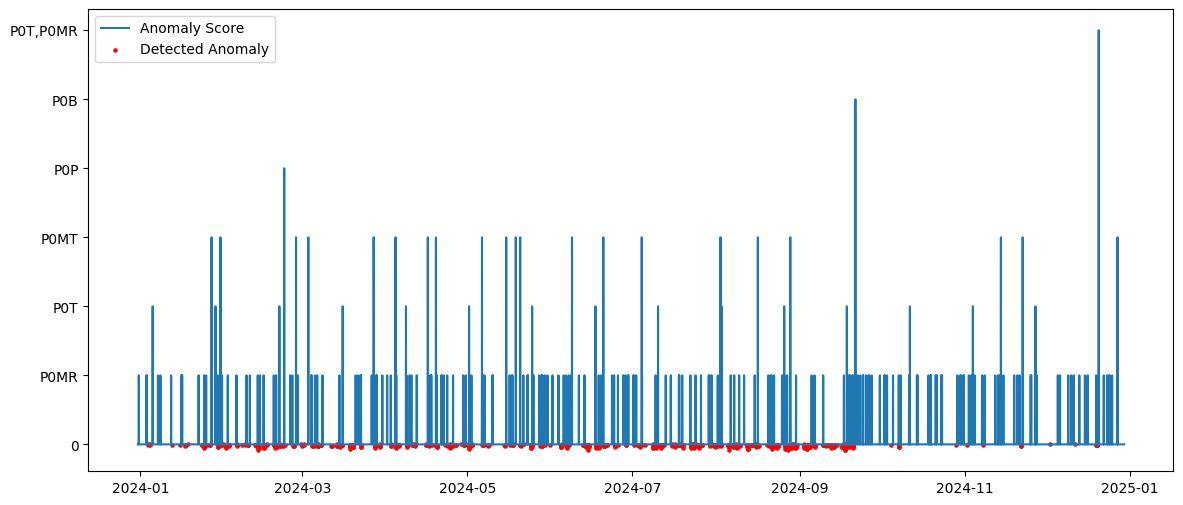

In [691]:

plt.figure(figsize=(14,6))
plt.plot(ev_test["TimeStamp"], ev_test["DTC"], label="Anomaly Score")
plt.scatter(ev_test.loc[ev_test["Anomaly"] == -1, "TimeStamp"],
            ev_test.loc[ev_test["Anomaly"] == -1, "Anomaly_Score"],
            color="red", label="Detected Anomaly", s=5)
plt.legend()
plt.show()

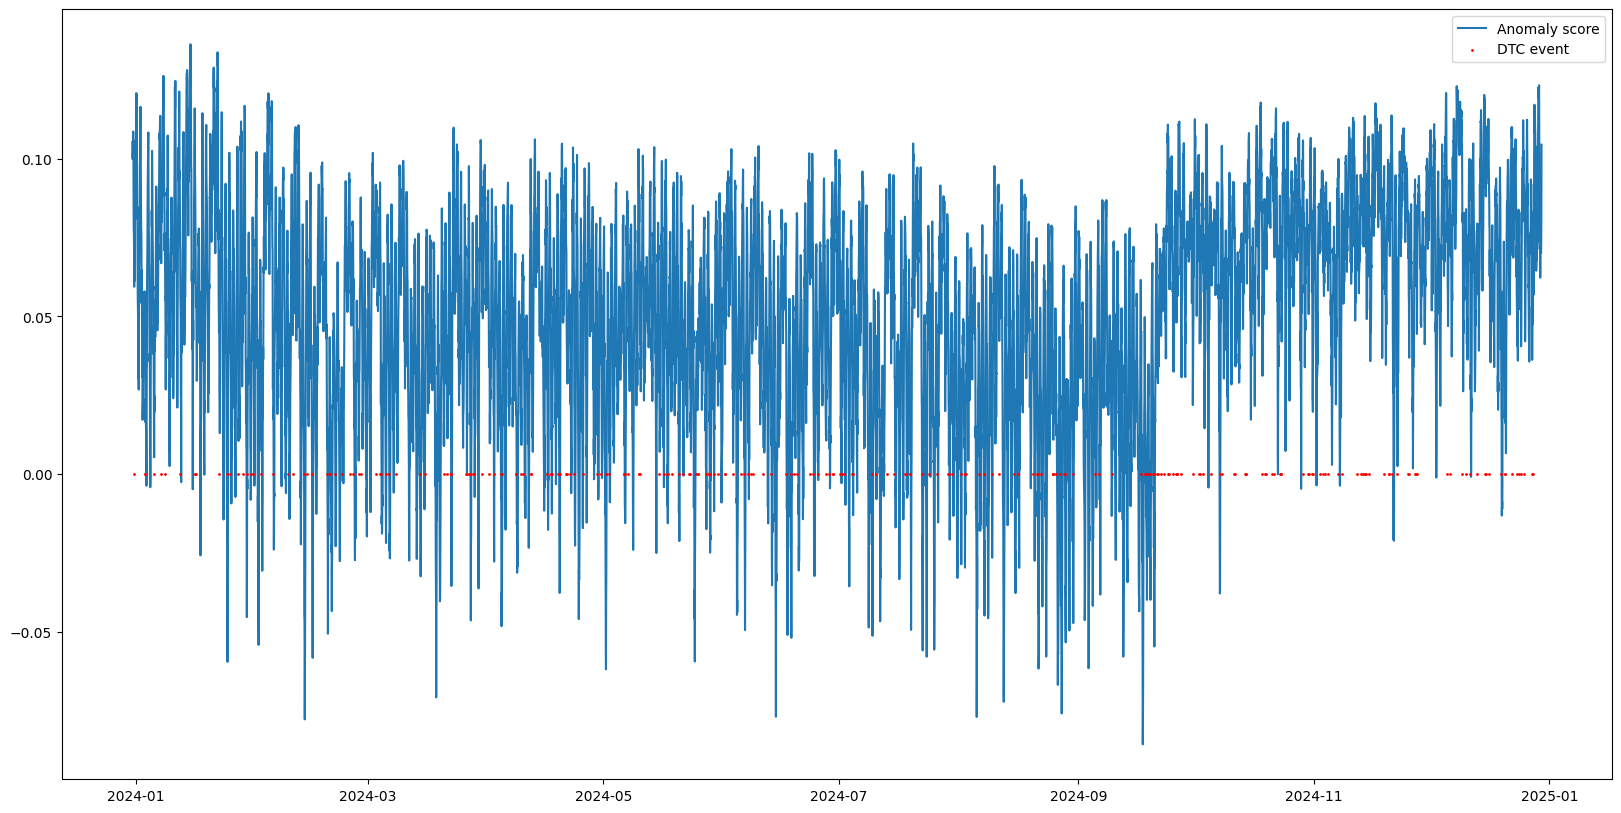

In [692]:
plt.figure(figsize=(20, 10))
plt.plot(ev_test["TimeStamp"], ev_test["Anomaly_Score"], label="Anomaly score", zorder=1)
plt.scatter(ev_test.loc[ev_test["DTC"] != "0", "TimeStamp"],
            [0]*len(ev_test[ev_test["DTC"] != "0"]), color="red", label="DTC event", s=1, zorder=2)
plt.legend()
plt.show()

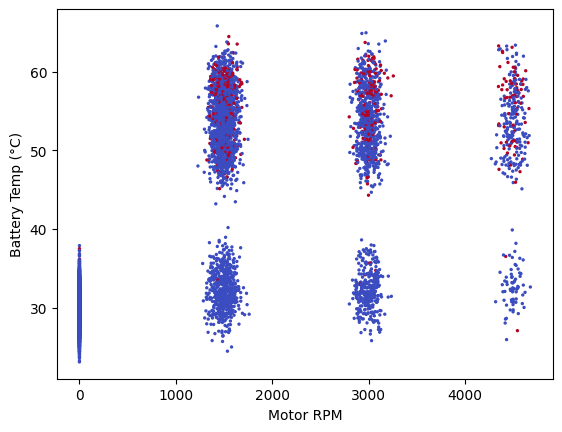

In [693]:
plt.scatter(ev_test["Motor_RPM"], ev_test["Battery_Temp"],
            c=(ev_test["Anomaly"] == -1), cmap="coolwarm", s=2)
plt.xlabel("Motor RPM")
plt.ylabel("Battery Temp (°C)")
plt.show()

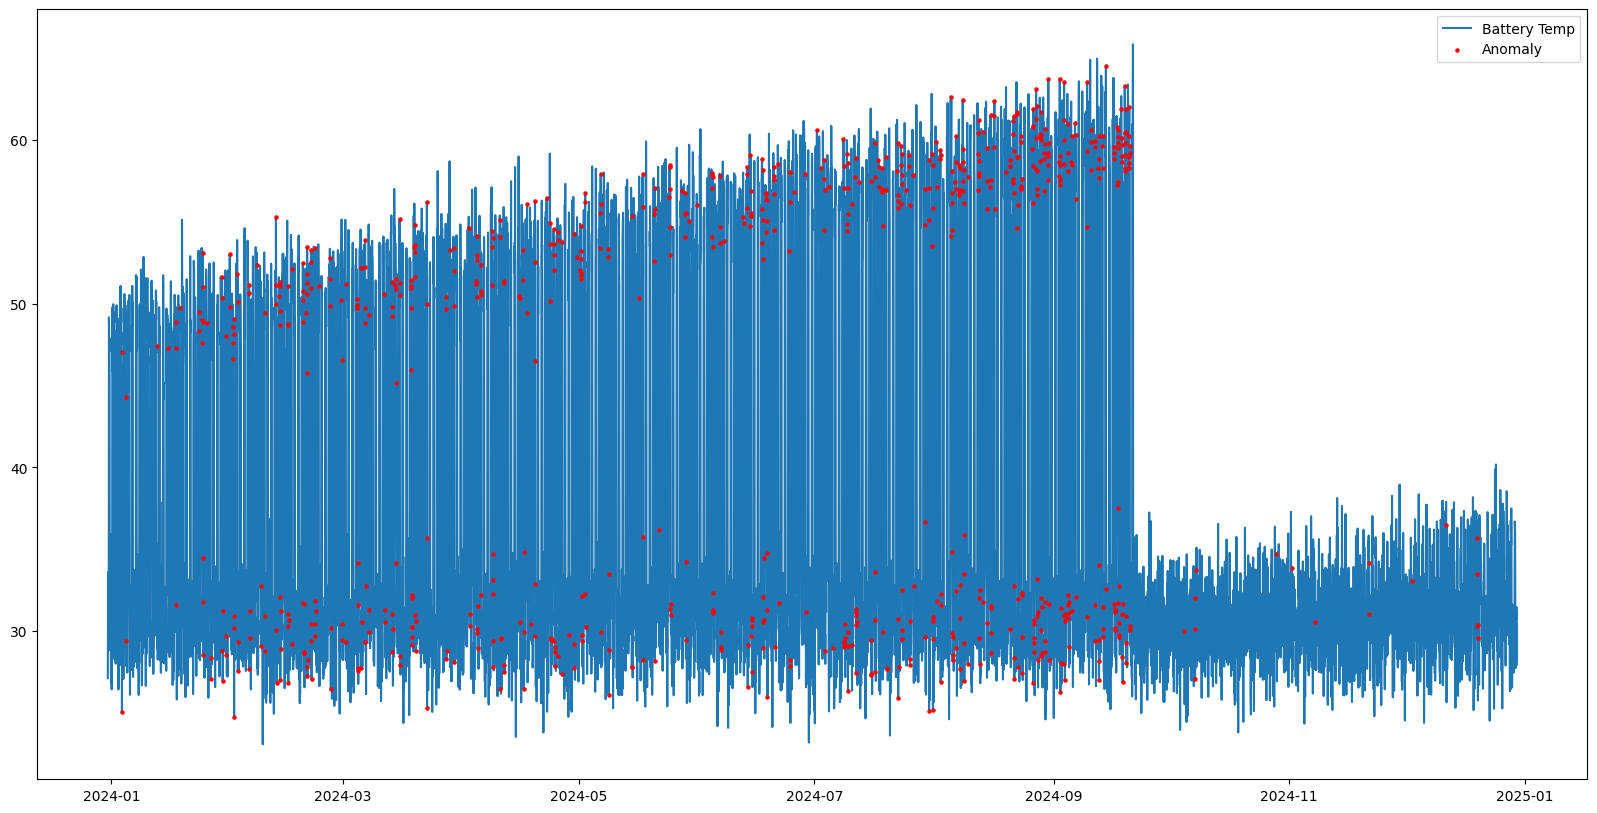

In [694]:
plt.figure(figsize=(20, 10))
plt.plot(ev_test["TimeStamp"], ev_test["Battery_Temp"], label="Battery Temp", zorder=1)
plt.scatter(ev_test.loc[ev_test["Anomaly"] == -1, "TimeStamp"],
            ev_test.loc[ev_test["Anomaly"] == -1, "Battery_Temp"],
            color="red", s=5, label="Anomaly", zorder=2)
plt.legend()
plt.show()

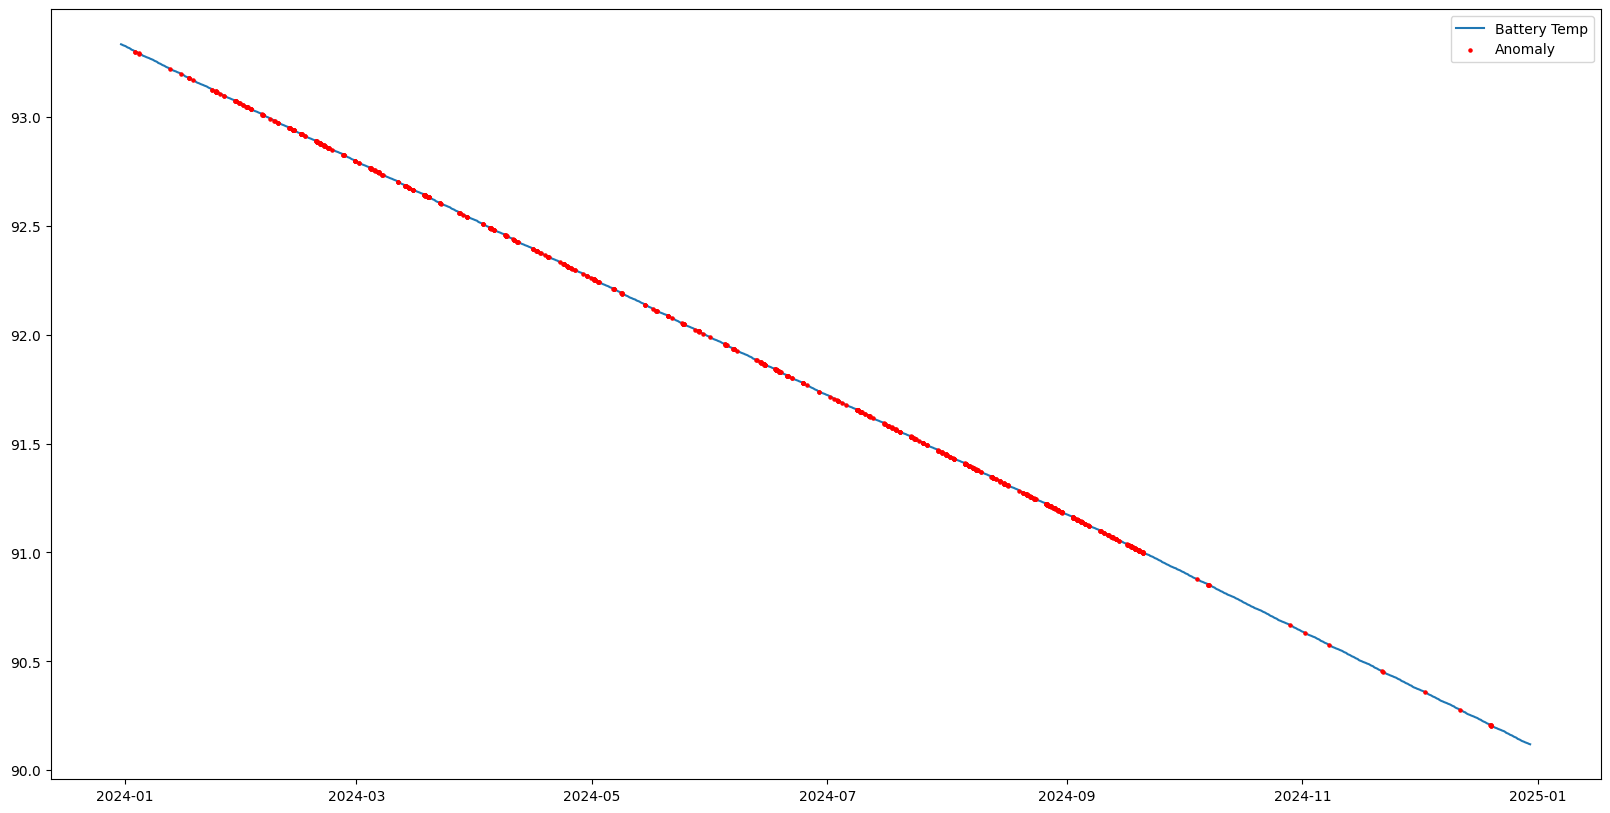

In [695]:
plt.figure(figsize=(20, 10))
plt.plot(ev_test["TimeStamp"], ev_test["SOH"], label="Battery Temp", zorder=1)
plt.scatter(ev_test.loc[ev_test["Anomaly"] == -1, "TimeStamp"],
            ev_test.loc[ev_test["Anomaly"] == -1, "SOH"],
            color="red", s=5, label="Anomaly", zorder=2)
plt.legend()
plt.show()

In [696]:
ev_test["Anomaly"].value_counts()

Anomaly
 1    7973
-1     785
Name: count, dtype: int64

In [697]:
ev_test["DTC"].value_counts()

DTC
0           8497
P0MR         222
P0MT          21
P0T           15
P0P            1
P0B            1
P0T,P0MR       1
Name: count, dtype: int64